# Analyse der Wikipedia Seite "Philosophie"

Zuerst die Seite einlesen:

In [3]:
url = "https://de.wikipedia.org/wiki/Philosophie"
headers = {'User-Agent': '(s0591752@htw-berlin.de)'}

print("URL:", url, "| Headers:", headers)

URL: https://de.wikipedia.org/wiki/Philosophie | Headers: {'User-Agent': '(s0591752@htw-berlin.de)'}


Dann den Seiteninhalt per request anfragen. Habe ihn noch in eine Extra Datei geschrieben, um ihn mir genauer anzusehen.

In [9]:
import requests as rq

raw_html = rq.get(url=url, headers=headers).content.decode()
raw_html

with open("./philo.html", "w") as w:
    w.write(raw_html)

Jetzt muss der Inhalt der Seite von der Rohen HTML getrennt werden. Dazu einfach den Code aus der [notebook.ipynb](notebook.ipynb) rippen und hier nutzen.

In [11]:
from html.parser import HTMLParser

class MyHTMLParser(HTMLParser):
    script = False
    res = ""
    def handle_starttag(self, tag, attrs):
        if tag.lower() in ["script","style"]:
            self.script = True
    def handle_endtag(self, tag):
        if tag.lower() in ["script","style"]:
            self.script = False
    def handle_data(self, data):
        if str.strip(data)=="" or self.script:
            return
        self.res += ' '+data.replace('[ edit ]','')

parser = MyHTMLParser()
parser.feed(raw_html)
page_content = parser.res

with open("./philo_content.txt", "w") as w:
    w.write(page_content)

print(page_content[:1000])

 Philosophie – Wikipedia Zum Inhalt springen Hauptmenü Hauptmenü In die Seitenleiste verschieben Verbergen 
		Navigation
	 Hauptseite Themenportale Zufälliger Artikel Spezialseiten 
		Mitmachen
	 Artikel verbessern Neuen Artikel anlegen Autorenportal Hilfe Letzte Änderungen Kontakt Suche Suchen Erscheinungsbild Jetzt spenden Benutzerkonto erstellen Anmelden Meine Werkzeuge Jetzt spenden Benutzerkonto erstellen Anmelden Inhaltsverzeichnis In die Seitenleiste verschieben Verbergen (Anfang) 1 Einführung Unterabschnitt Einführung umschalten 1.1 Begriffsdefinition 1.2 Sinn und Arten des Philosophierens 1.3 Methoden 2 Begriffsgeschichte 3 Wissenschaftsgeschichte 4 Disziplinen Unterabschnitt Disziplinen umschalten 4.1 Allgemein 4.2 Abgrenzung theoretische und praktische Philosophie 4.3 Theoretische Philosophie 4.3.1 Logik 4.3.2 Erkenntnistheorie 4.3.3 Wissenschaftstheorie 4.3.4 Metaphysik und Ontologie 4.3.5 Sprachphilosophie 4.4 Praktische Philosophie 4.4.1 Ethik und Metaethik 4.4.2 Rechtsph

Nun zum spaßigen Teil: dem Auswerten/Anzeigen der Daten.
Wir nutzen Rake, weil das in der VL auch so gemacht wurde. Damit kann man wohl Wörter nach Häufigkeiten filtern.

In [21]:
import nlp_rake as rk

rake = rk.Rake(
    min_chars=3,
    max_words=3,
    min_freq=8,
    language_code='de',
    stopwords=None,  # {'and', 'of'}
    lang_detect_threshold=50,
    max_words_unknown_lang=2,
    generated_stopwords_percentile=80,
    generated_stopwords_max_len=3,
    generated_stopwords_min_freq=2,
)

res = rake.apply(
        page_content,
        text_for_stopwords=None,
    )

res


[('→ hauptartikel', 4.105555555555555),
 ('immanuel kant', 3.9444444444444446),
 ('theoretische philosophie', 3.649501661129568),
 ('fragen', 2.0),
 ('philosophie', 1.7209302325581395),
 ('selbst', 1.6428571428571428),
 ('platon', 1.619047619047619),
 ('welt', 1.56),
 ('metaphysik', 1.5454545454545454),
 ('gibt', 1.5333333333333334),
 ('menschen', 1.5185185185185186),
 ('ethik', 1.4736842105263157),
 ('frage', 1.4736842105263157),
 ('aristoteles', 1.4210526315789473),
 ('jahrhundert', 1.4090909090909092),
 ('einführung', 1.4),
 ('allem', 1.3571428571428572),
 ('sondern', 1.3125),
 ('wissenschaft', 1.3076923076923077),
 ('mensch', 1.3),
 ('welche', 1.2666666666666666),
 ('geschichte', 1.25),
 ('vgl', 1.25),
 ('natur', 1.1111111111111112),
 ('chr', 1.0),
 ('wissenschaftstheorie', 1.0),
 ('hrsg', 1.0)]

Jetzt wollen wir das Ergebnis mal zeichnen. Die Zahl hinter den Keywords ist der "Rake-Score". Dieser gibt quasi die Relevanz eines Keywords an und wird aus Häufigkeit des Keywords und Kombinationen mit anderen Keywords gebildet. Je höher, desto relevanter das Keyword.

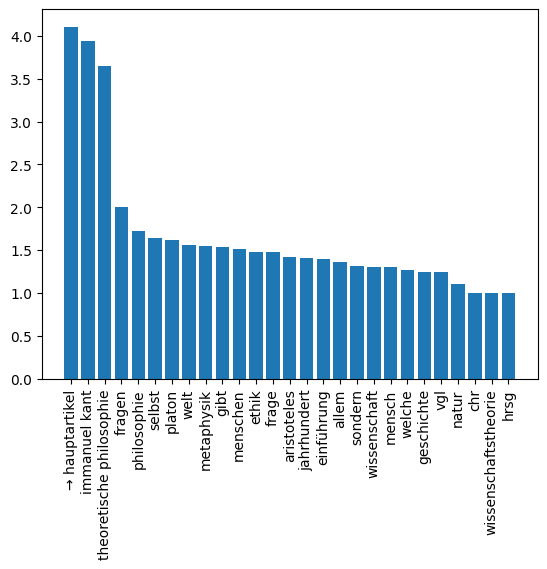

In [22]:
import matplotlib.pyplot as plt

def plot(pair_list):
    k,v = zip(*pair_list)
    plt.bar(range(len(k)),v)
    plt.xticks(range(len(k)),k,rotation='vertical')
    plt.show()

plot(res)

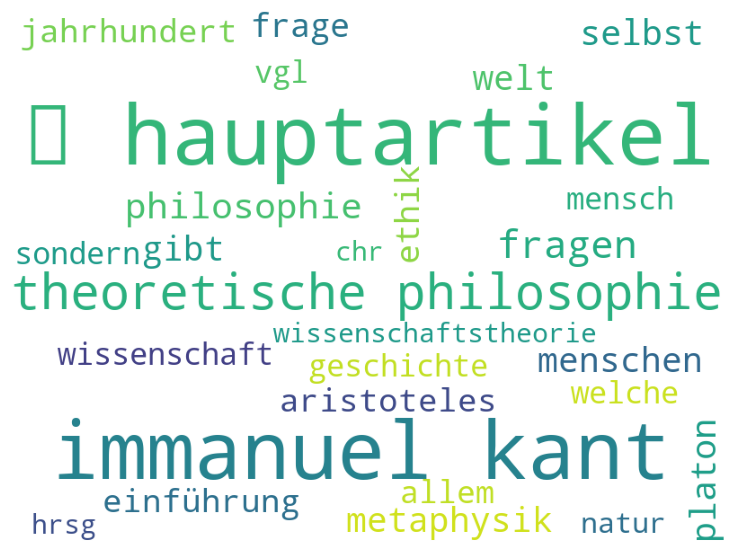

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(background_color='white',width=800,height=600)
plt.figure(figsize=(15,7))
plt.axis("off")
plt.imshow(wc.generate_from_frequencies({ k:v for k,v in res }))